In [1]:
# notebook for building CNN with cats & dogs dataset

In [2]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import random

### Importing the raw cat and dog images

In [4]:
# importing the data (cat and dog images)

data_dir = "../Data/cats_dogs"

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


#### To check if tf can access any GPU you have on your machine

In [5]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


In [6]:
# View labels from the first training batch

for images, labels in train_ds_raw.take(1):

    print(labels.numpy())
    print(train_ds_raw.class_names)

[0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1]
['cats_set', 'dogs_set']


In [7]:
# class names
class_names = train_ds_raw.class_names
print(class_names)

['cats_set', 'dogs_set']


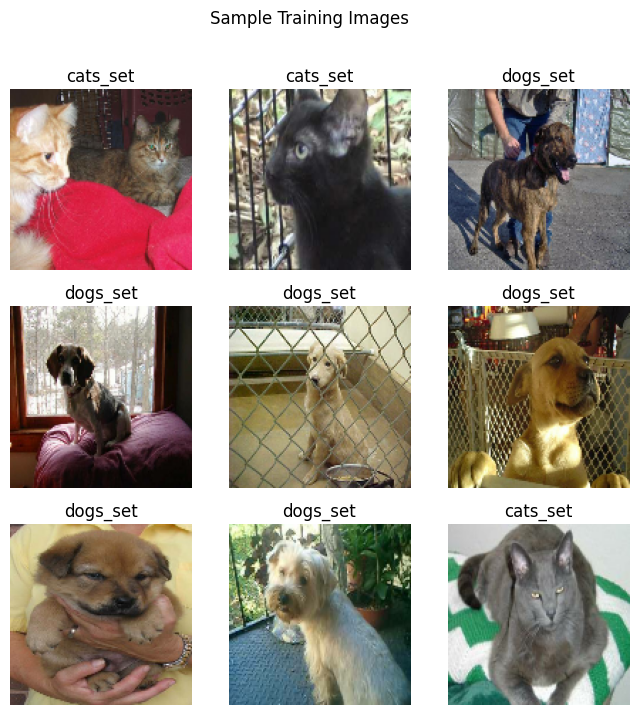

In [8]:
# View one batch of images
plt.figure(figsize=(8, 8))

for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # display 0–255 RGB correctly
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

### Importing padded cat and dog images

In [9]:
# Re-import images with aspect-ratio preservation (padded instead of raw)

train_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # target size for all images
    batch_size=32,                              # number of images per batch
    pad_to_aspect_ratio=True                    # preserve image proportions and pad instead of stretching
)

val_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same target size
    batch_size=32,                              # same batch size
    pad_to_aspect_ratio=True                    # apply same preprocessing to validation data
)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 25
Validation batches: 4
Test batches: 3


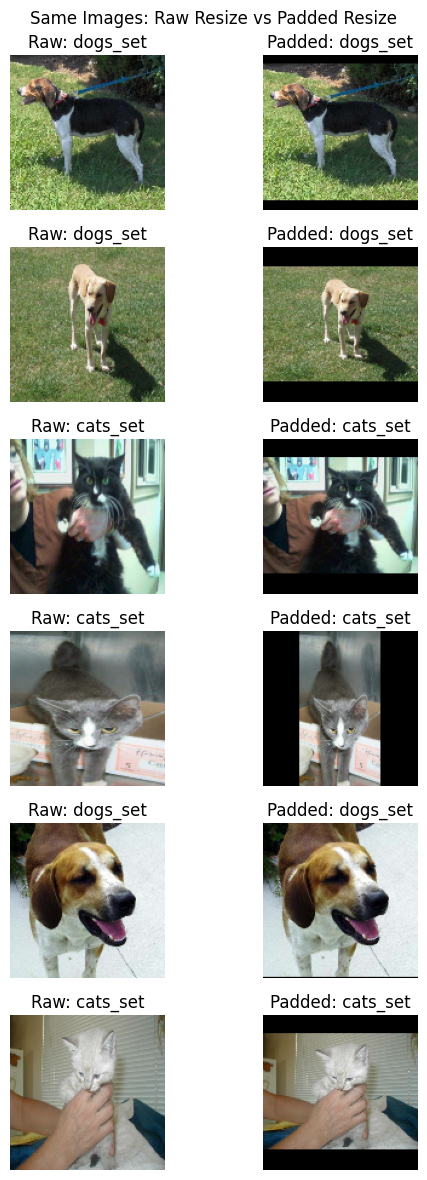

In [10]:
random.seed(42)

cat_paths = list(Path(data_dir).glob("cats_set/*"))
dog_paths = list(Path(data_dir).glob("dogs_set/*"))

image_paths = random.sample(cat_paths, 3) + random.sample(dog_paths, 3)
random.shuffle(image_paths)

plt.figure(figsize=(6, 12))

for i, path in enumerate(image_paths):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)

    raw_img = tf.image.resize(img, (128, 128))
    padded_img = tf.image.resize_with_pad(img, 128, 128)

    label = path.parent.name

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(raw_img.numpy().astype("uint8"))
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(padded_img.numpy().astype("uint8"))
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()

### Normalize all data and shuffle train data

In [11]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

# Shuffle only the training data to improve learning 
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

In [12]:
# check normalization worked correctly (should be 0–1 range)
for images, labels in train_ds_padded.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 1.0


### Building the MLP model

In [13]:
# set random seed for reproducibility
tf.random.set_seed(42)  

# Define the MLP model
mlp_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),       # input is a 128x128 color image
    layers.Flatten(),                        # convert image to a 1D vector (loses spatial structure)
    layers.Dense(128, activation="relu"),    # hidden layer learns patterns from pixel values
    layers.Dense(64, activation="relu"),     # deeper representation of patterns
    layers.Dense(1, activation="sigmoid")    # output: probability of one class (binary classification)
])

# Compile the model
mlp_catdog.compile(
    optimizer="adam",                        # optimization algorithm
    loss="binary_crossentropy",              # loss for binary classification
    metrics=["accuracy"]                     # track accuracy during training
)

# summary of the MLP model architecture
mlp_catdog.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# train the MLP model
mlp_history = mlp_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=10
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_catdog.evaluate(test_ds_padded, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5138 - loss: 3.1094 - val_accuracy: 0.6154 - val_loss: 0.9323
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5713 - loss: 0.8776 - val_accuracy: 0.5288 - val_loss: 1.0047
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5962 - loss: 0.7246 - val_accuracy: 0.5288 - val_loss: 0.8751
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6062 - loss: 0.7937 - val_accuracy: 0.4712 - val_loss: 1.7772
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5838 - loss: 0.9267 - val_accuracy: 0.5096 - val_loss: 1.2314
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6675 - loss: 0.7302 - val_accuracy: 0.5288 - val_loss: 0.7663
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7525 - loss: 0.5154 - val_accuracy: 0.5577 - val_loss: 0.9903
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7250 - loss: 0.5370 - val_accuracy: 0.5288 - v

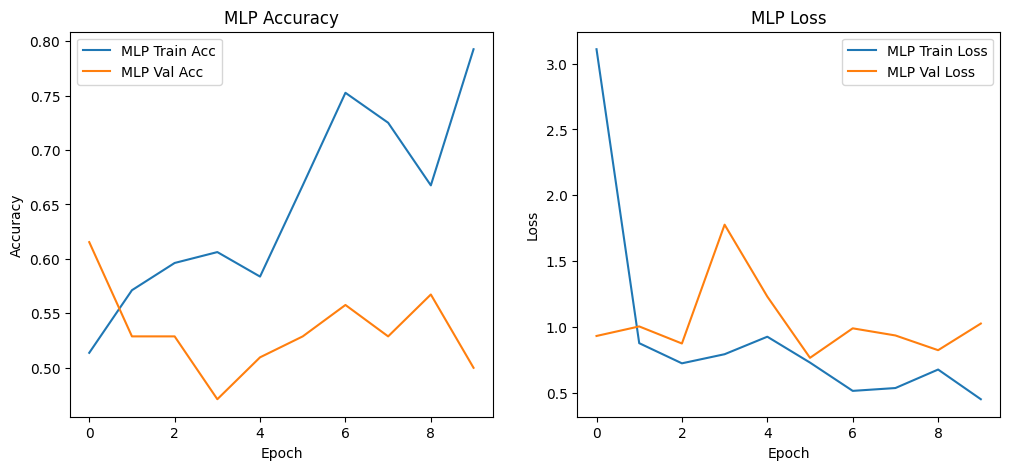

In [15]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Building CNN model

In [16]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20                                      # increase if needed
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.5575 - loss: 0.8529 - val_accuracy: 0.5385 - val_loss: 0.6997
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.6313 - loss: 0.6378 - val_accuracy: 0.5096 - val_loss: 0.7311
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.7350 - loss: 0.5396 - val_accuracy: 0.5385 - val_loss: 0.7859
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.8125 - loss: 0.4208 - val_accuracy: 0.5481 - val_loss: 0.7839
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.8625 - loss: 0.3201 - val_accuracy: 0.6346 - val_loss: 0.8687
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9150 - loss: 0.2212 - val_accuracy: 0.5962 - val_loss: 0.9900
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.9550 - loss: 0.1404 - val_accuracy: 0.6058 - val_loss: 0.8739
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9900 - loss: 0.0856 - val_accuracy: 0.

### Visualizing CNN performance

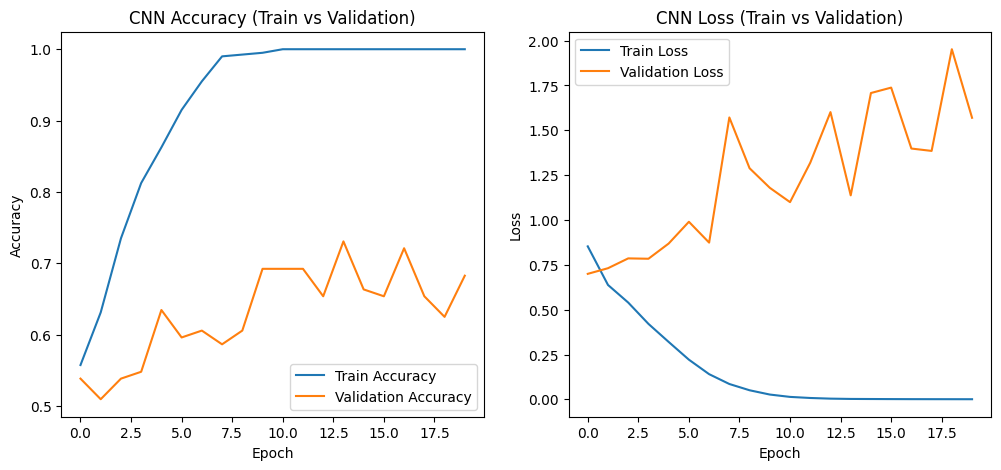

In [17]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### CNN with early stopping

In [18]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",                         # watch validation loss
    patience=5,                                 # stop if no improvement for 5 epochs
    restore_best_weights=True                   # revert to best model after stopping
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    callbacks=[early_stopping]                     # add early stopping callback
)                   

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5562 - loss: 0.8056 - val_accuracy: 0.5865 - val_loss: 0.6806
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.6062 - loss: 0.6648 - val_accuracy: 0.4615 - val_loss: 0.7273
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.6625 - loss: 0.6234 - val_accuracy: 0.6058 - val_loss: 0.6570
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.6900 - loss: 0.5749 - val_accuracy: 0.5481 - val_loss: 0.6984
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.7425 - loss: 0.5203 - val_accuracy: 0.5577 - val_loss: 0.7163
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.8188 - loss: 0.4056 - val_accuracy: 0.6154 - val_loss: 0.7582
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.8775 - loss: 0.2891 - val_accuracy: 0.5385 - val_loss: 0.7887
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.9425 - loss: 0.1795 - val_accuracy: 0.

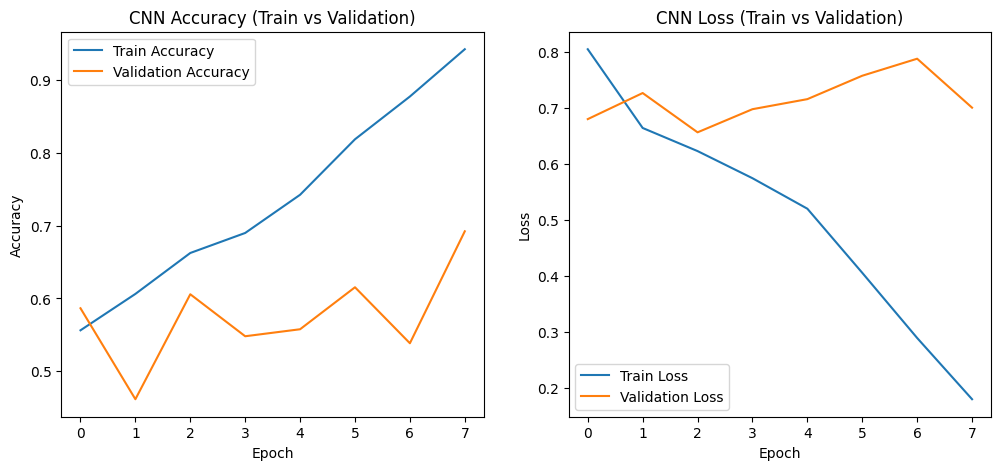

In [19]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Does CNN performance improve with data augmentation?

In [20]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

# define CNN model with data augmentation
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),          # input: 128x128 RGB image

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile augmented CNN model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train augmented CNN model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
)

# evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.5213 - loss: 1.0522 - val_accuracy: 0.5192 - val_loss: 0.6935
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.5888 - loss: 0.6742 - val_accuracy: 0.5481 - val_loss: 0.6970
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.6338 - loss: 0.6474 - val_accuracy: 0.4904 - val_loss: 0.7319
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.6637 - loss: 0.6155 - val_accuracy: 0.5288 - val_loss: 0.7420
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.6875 - loss: 0.5878 - val_accuracy: 0.5769 - val_loss: 0.6795
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.6725 - loss: 0.5954 - val_accuracy: 0.5481 - val_loss: 0.7096
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.7225 - loss: 0.5619 - val_accuracy: 0.5962 - val_loss: 0.6899
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.7138 - loss: 0.5538 - val_accuracy: 0.

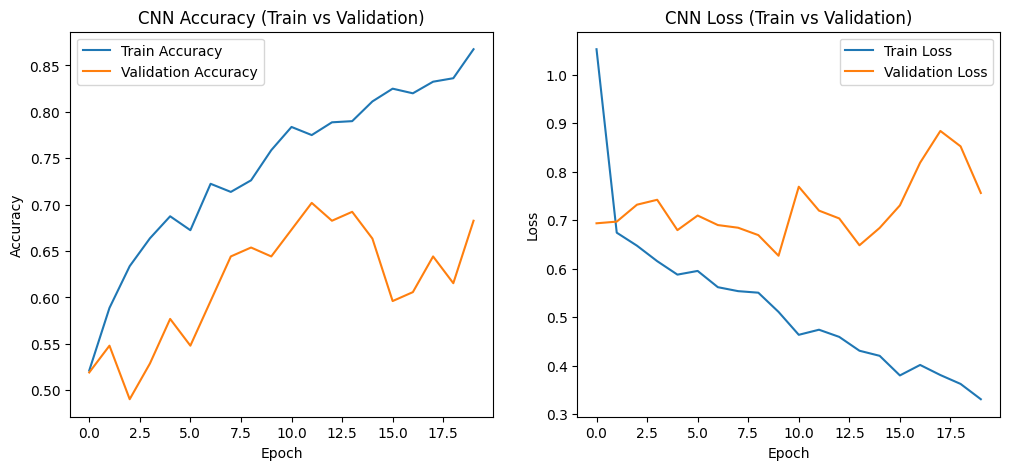

In [21]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code for you to experiment with

Use the code cell below as a starting point. Train at least 3 different CNN models by changing augmentation, regularization, and/or model capacity. Examples include adding rotation, zoom, L2 regularization, dropout, or another convolutional layer. Compare training, validation, and test performance, and explain which model generalizes best.

In [22]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.5337 - loss: 0.7813 - val_accuracy: 0.4904 - val_loss: 0.6922
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.5950 - loss: 0.6672 - val_accuracy: 0.5288 - val_loss: 0.7298
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.6288 - loss: 0.6445 - val_accuracy: 0.5288 - val_loss: 0.7099
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - accuracy: 0.6888 - loss: 0.5856 - val_accuracy: 0.5577 - val_loss: 0.7051
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.6963 - loss: 0.5528 - val_accuracy: 0.5865 - val_loss: 0.6959
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.7538 - loss: 0.5049 - val_accuracy: 0.6538 - val_loss: 0.6757
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.7925 - loss: 0.4314 - val_accuracy: 0.6058 - val_loss: 0.8047
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.8438 - loss: 0.3551 - val_accuracy: 0.

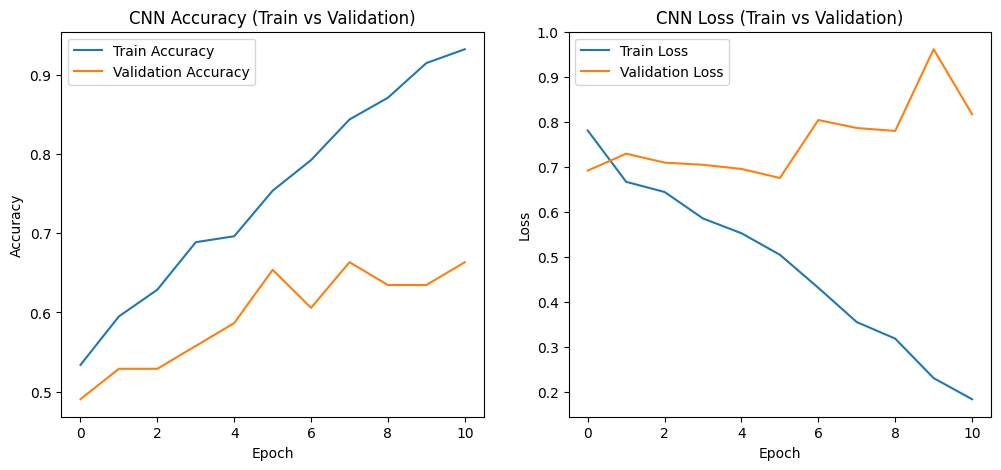

In [23]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code cells for your 3+ models. Make sure to annotate for each, explaining what you tried

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.5387 - loss: 0.6966 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.6175 - loss: 0.6608 - val_accuracy: 0.6250 - val_loss: 0.7130
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.6488 - loss: 0.6165 - val_accuracy: 0.6250 - val_loss: 0.7168
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.6850 - loss: 0.5815 - val_accuracy: 0.6923 - val_loss: 0.6375
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.7050 - loss: 0.5578 - val_accuracy: 0.5865 - val_loss: 0.7652
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.7412 - loss: 0.5080 - val_accuracy: 0.6346 - val_loss: 0.6309
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.7675 - loss: 0.4859 - val_accuracy: 0.6538 - val_loss: 0.6208
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - accuracy: 0.8225 - loss: 0.4223 - val_accuracy: 0.

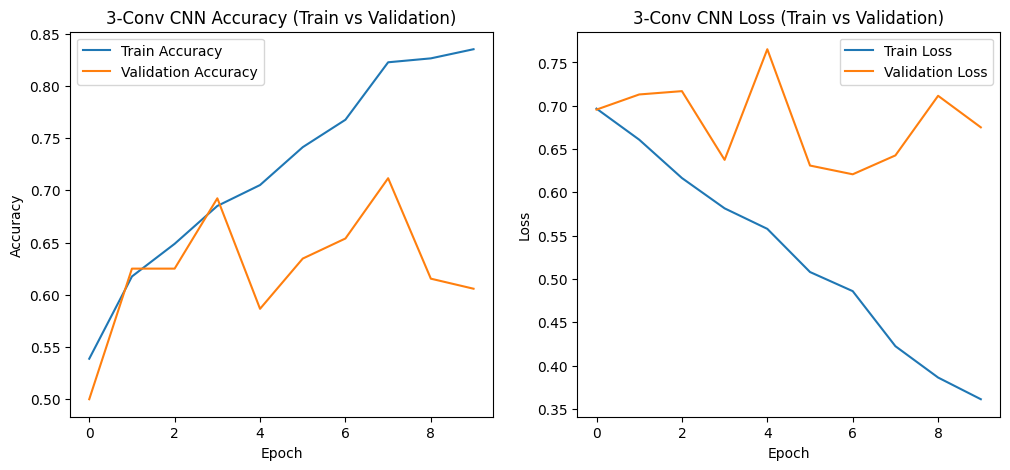

In [28]:
# Model 1: 3 convolutional blocks + horizontal flip augmentation
# ReLU is the usual choice for hidden CNN layers (fast training, avoids vanishing gradients).
# Alternatives like tanh or leaky_relu are fine to try, but ReLU is the default baseline.
# Sigmoid stays on the output layer for binary cat/dog classification.

data_augmentation_1 = models.Sequential([
    layers.RandomFlip("horizontal"),
])

early_stopping_1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

tf.random.set_seed(42)

cnn_3conv_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation_1,

    # First convolution block
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block (added capacity)
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

cnn_3conv_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_3conv_history = cnn_3conv_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_1]
)

cnn_3conv_test_loss, cnn_3conv_test_acc = cnn_3conv_catdog.evaluate(test_ds_padded)
print(f"3-layer CNN test accuracy: {cnn_3conv_test_acc:.4f}")

# Train vs validation accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_3conv_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_3conv_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("3-Conv CNN Accuracy (Train vs Validation)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_3conv_history.history["loss"], label="Train Loss")
plt.plot(cnn_3conv_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("3-Conv CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.5325 - loss: 1.0253 - val_accuracy: 0.4712 - val_loss: 0.8237
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.5800 - loss: 0.7705 - val_accuracy: 0.4231 - val_loss: 0.8150
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.6438 - loss: 0.7142 - val_accuracy: 0.4904 - val_loss: 0.7967
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.6700 - loss: 0.6939 - val_accuracy: 0.4712 - val_loss: 0.7815
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.7150 - loss: 0.6601 - val_accuracy: 0.6058 - val_loss: 0.7420
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.7362 - loss: 0.6115 - val_accuracy: 0.6154 - val_loss: 0.7645
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.7500 - loss: 0.5961 - val_accuracy: 0.5577 - val_loss: 0.8169
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.7675 - loss: 0.5629 - val_accuracy: 0.

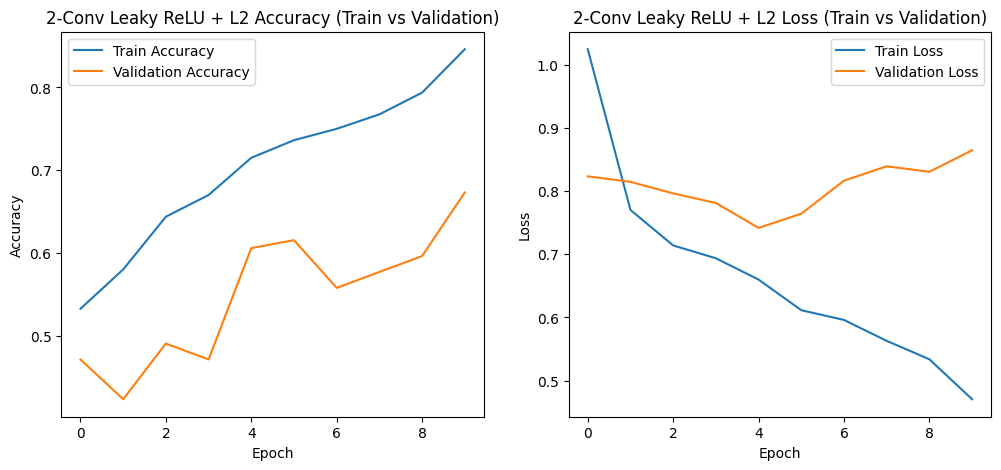

In [29]:
# Model 2: 2 convolutional blocks + leaky_relu + L2 regularization
# L2 penalizes large weights to reduce overfitting; 0.0005 matches the template above.

data_augmentation_2 = models.Sequential([
    layers.RandomFlip("horizontal"),
])

early_stopping_2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

tf.random.set_seed(42)

l2_reg = regularizers.l2(0.0005)

cnn_2conv_l2_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation_2,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=l2_reg
    ),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=l2_reg
    ),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(
        64,
        activation="leaky_relu",
        kernel_regularizer=l2_reg
    ),
    layers.Dense(1, activation="sigmoid")
])

cnn_2conv_l2_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_2conv_l2_history = cnn_2conv_l2_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_2]
)

cnn_2conv_l2_test_loss, cnn_2conv_l2_test_acc = cnn_2conv_l2_catdog.evaluate(test_ds_padded)
print(f"2-layer leaky_relu + L2 CNN test accuracy: {cnn_2conv_l2_test_acc:.4f}")

# Train vs validation accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_2conv_l2_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_2conv_l2_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("2-Conv Leaky ReLU + L2 Accuracy (Train vs Validation)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_2conv_l2_history.history["loss"], label="Train Loss")
plt.plot(cnn_2conv_l2_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-Conv Leaky ReLU + L2 Loss (Train vs Validation)")
plt.legend()

plt.show()

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.5512 - loss: 0.8427 - val_accuracy: 0.6058 - val_loss: 0.8037
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - accuracy: 0.5913 - loss: 0.7842 - val_accuracy: 0.4808 - val_loss: 0.9012
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.5925 - loss: 0.7746 - val_accuracy: 0.6154 - val_loss: 0.7501
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.5987 - loss: 0.7523 - val_accuracy: 0.5865 - val_loss: 0.7635
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.6425 - loss: 0.7232 - val_accuracy: 0.6346 - val_loss: 0.7800
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.6562 - loss: 0.7047 - val_accuracy: 0.5577 - val_loss: 0.8078
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - accuracy: 0.6687 - loss: 0.6937 - val_accuracy: 0.6058 - val_loss: 0.8247
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - accuracy: 0.6888 - loss: 0.6724 - val_accuracy: 0.

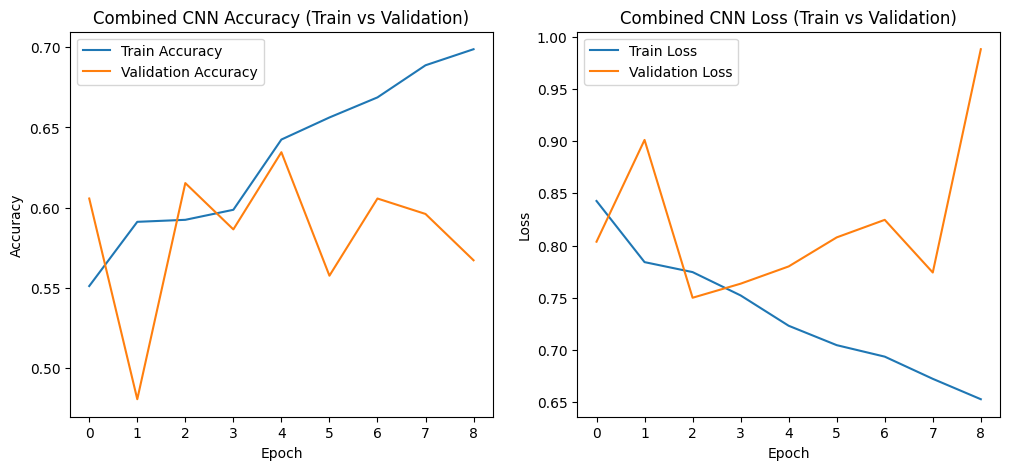

In [32]:
# Model 3: combines Model 1 (3 conv blocks) + Model 2 (leaky_relu, L2)
# with stronger augmentation: rotation, zoom, contrast, and Gaussian blur.

data_augmentation_3 = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.15),
    layers.RandomGaussianBlur(factor=(0.25, 0.75), kernel_size=3),
])

early_stopping_3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

tf.random.set_seed(42)

l2_reg = regularizers.l2(0.0005)

cnn_combined_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation_3,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=l2_reg
    ),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=l2_reg
    ),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_regularizer=l2_reg
    ),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(
        64,
        activation="leaky_relu",
        kernel_regularizer=l2_reg
    ),
    layers.Dense(1, activation="sigmoid")
])

cnn_combined_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_combined_history = cnn_combined_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_3]
)

cnn_combined_test_loss, cnn_combined_test_acc = cnn_combined_catdog.evaluate(test_ds_padded)
print(f"Combined 3-conv + leaky_relu + L2 + aug CNN test accuracy: {cnn_combined_test_acc:.4f}")

# Train vs validation accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_combined_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_combined_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Combined CNN Accuracy (Train vs Validation)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_combined_history.history["loss"], label="Train Loss")
plt.plot(cnn_combined_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Combined CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 280ms/step - accuracy: 0.4750 - loss: 0.9134 - val_accuracy: 0.5577 - val_loss: 0.8682
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.5325 - loss: 0.8523 - val_accuracy: 0.5962 - val_loss: 0.8253
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 456ms/step - accuracy: 0.5688 - loss: 0.8163 - val_accuracy: 0.5481 - val_loss: 0.8171
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 134s 6s/step - accuracy: 0.6025 - loss: 0.7908 - val_accuracy: 0.5192 - val_loss: 0.8094
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 398ms/step - accuracy: 0.5838 - loss: 0.7774 - val_accuracy: 0.5962 - val_loss: 0.7730
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 797ms/step - accuracy: 0.5888 - loss: 0.7571 - val_accuracy: 0.5000 - val_loss: 0.8147
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 168s 7s/step - accuracy: 0.6000 - loss: 0.7326 - val_accuracy: 0.5673 - val_loss: 0.7910
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 378ms/step - accuracy: 0.6313 - loss: 0.7216 - val_accuracy: 

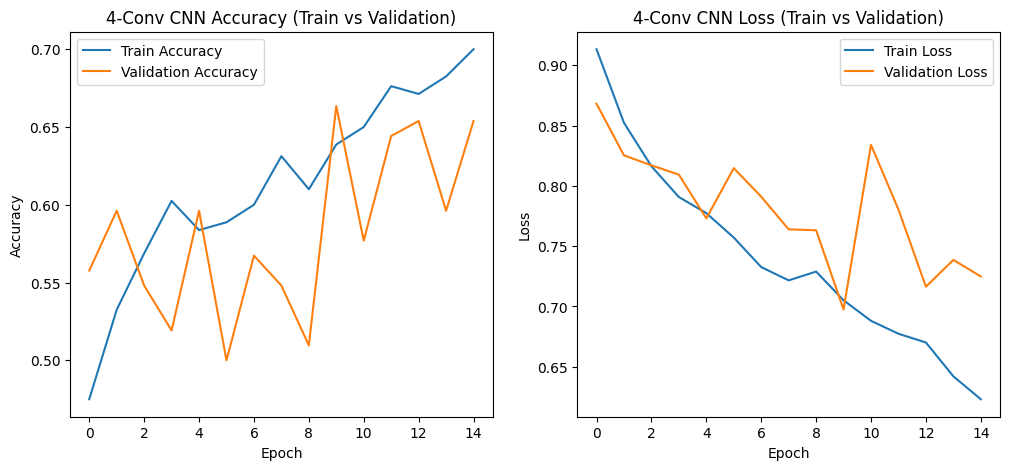

In [33]:
# Model 4: 4 convolutional blocks (extra depth vs Model 3)
# Same leaky_relu + L2 + augmentation stack as Model 3.

data_augmentation_4 = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.15),
    layers.RandomGaussianBlur(factor=(0.25, 0.75), kernel_size=3),
])

early_stopping_4 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

tf.random.set_seed(42)

l2_reg = regularizers.l2(0.0005)

cnn_4conv_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation_4,

    layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=l2_reg),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=l2_reg),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=l2_reg),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding="same", kernel_regularizer=l2_reg),
    layers.Activation("leaky_relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="leaky_relu", kernel_regularizer=l2_reg),
    layers.Dense(1, activation="sigmoid")
])

cnn_4conv_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_4conv_history = cnn_4conv_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_4]
)

cnn_4conv_test_loss, cnn_4conv_test_acc = cnn_4conv_catdog.evaluate(test_ds_padded)
print(f"4-layer CNN test accuracy: {cnn_4conv_test_acc:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_4conv_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_4conv_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("4-Conv CNN Accuracy (Train vs Validation)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_4conv_history.history["loss"], label="Train Loss")
plt.plot(cnn_4conv_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("4-Conv CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### What seemed to help model performance most in your experiments?

Adding more convolutional layers helped the most. I think deeper models could learn probably better spatial features, which mattered more for separating cats and dogs than the smaller tweaks I tried
.

